# 로지스틱 회귀
- 퍼셉트론과 아달린보다 발전한 형태(선형회귀는 값을 예측, 로지스틱 회귀는 값을 분류)  
<img src="img/w.png" alt="image.png" style="width:500px;" />
- 활성화 함수는 비선형 함수를 사용한다
    - 활성화 함수가 선형 함수라면 무의미
    - $a=w_1x_1 + w_2x_2 + ... + w_mx_m$  
        $y = ka$  
        $y = k(w_1x_1 + w_2x_2 + ... + w_mx_m)$  -->  활성화 함수의 의미가 없다.

#### 시그모이드 함수
- z를 0~1 사이의 값으로 변환하는 함수
- $z = \sum_{i=1}^m w_ix_i$
- 만드는 과정: 오즈 비 > 로짓 함수 > 시그모이드 함수  
<img src="img/x.png" alt="image.png" style="width:1000px;" />
- 오즈 비(OR(odds ratio)): 사건이 발생할 확률과 발생하지 않을 확률의 비율
    - $odds = \frac{p}{1-p}$
- 로짓(로지스틱) 함수: 오즈 비의 로그값
    - $lnit = ln(\frac{p}{1-p})$
- 시그모이드 함수  
    - $sigmoid = \frac{1}{1+e^{-z}}$

<img src="img/y.png" alt="image.png" style="width:700px;" />

#### 로지스틱 손실 함수
- 크로스 엔트로피(cross entropy) 손실 함수의 이진 버전.(로지스틱 함수랑 다름!)
- $L = -[yln(a) + (1-y)ln(1-a)]$ ($y$: 타깃 값, $a$: 활성화 함수의 출력값)

||L|
|---|---|
|y=1 ( 양성 클래스 )|$-ln(a)$|
|y=0 ( 음성 클래스 )|$-ln(1-a)$|

*y에 따라서 a 의 값이 우리가 원하는 목표치가 된다.*

- $\frac{\partial L}{\partial w_i} = -(y-a)x_i$  
- $\frac{\partial L}{\partial b} = -(y-a) \cdot 1$

<img src="img/z.png" alt="image.png" style="width:700px;" />

- 로지스틱 손실 함수로 가중치와 절편 업데이터
    - $w_i = w_i - \frac{\partial L}{\partial w_i} = w_i + (y-a)x_i$
    - $b = b - \frac{\partial L}{\partial b} = b + (y-a) \cdot 1$

#### 활성화 함수(Activation Function)
- 은닉층과 출력층의 뉴런에서 출력값을 결정하는 함수
- 비선형 함수(Non-linear function)를 사용한다.
1) 계단 함수(Step Function): *실제로 거의 사용되지 않음*
2) 시그모이드 함수(Sigmoid function): 0과 1 사이의 값을 출력하는 S자 형태의 함수
3) 하이퍼볼릭 탄젠트 함수(Hyperbolic Tangent function): -1과 1 사이의 값을 출력하는 S자 형태의 함수

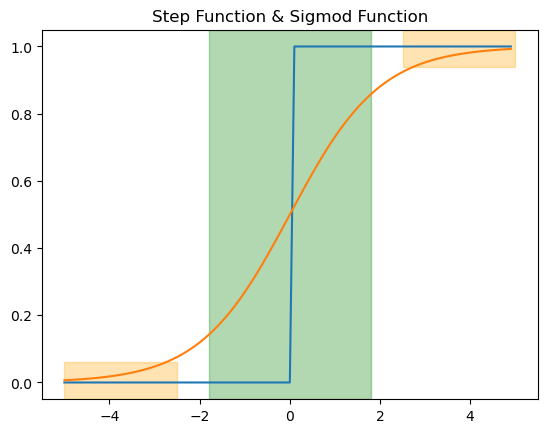

In [84]:
# 계단 함수와 시그모이드 함수
import numpy as np
import matplotlib.pyplot as plt

def step(x):
    return np.array(x>0, dtype=np.int32)

def sigmoid(x):
    return 1/(1+np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y1 = step(x)
y2 = sigmoid(x)
plt.title('Step Function & Sigmod Function')
plt.plot(x, y1)
plt.plot(x, y2)

plt.axvspan(-1.8, 1.8, color='green', alpha=0.3)
plt.axvspan(-5, -2.5, 0.0, 0.1, color='orange', alpha=0.3)
plt.axvspan(2.5, 5, 0.9, 1.0, color='orange', alpha=0.3)

plt.show()

#### 시그모이드 함수와 기울기 소실
- 위의 주황색 구간에서는 미분값이 0에 가까운 자주 작은 값
- 초록색 구간에서는 최댓값이 0.25
- 기울기 소실(Vanishing Gradient) 문제: 시그모이드 함수의 출력이 0 또는 1에 가까워질 때, 기울기가 매우 작아져서 가중치 업데이트가 거의 이루어지지 않는 현상  
<img src="img/za.png" alt="image.png" style="width:500px;" />

#### 하이퍼볼릭탄젠트(Hyperbolic tangent function) 함수
- 입력값은 -1과 1 사이의 값으로 반환
- 미분했을 때 최댓값은 1
- 시그모이드 함수보다는 기울기 소실 증상이 적음
- 은닉층에서 시그모이드 함수보다 선호됨.

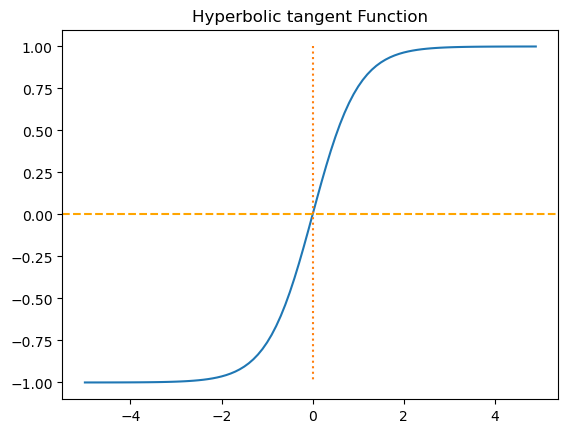

In [88]:
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(-5.0, 5.0, 0.1)
y = np.tanh(x)

plt.title('Hyperbolic tangent Function')
plt.plot(x, y)

plt.plot([0,0], [1.0, -1.0], ':')
plt.axhline(y=0, color='orange', linestyle='--')

plt.show()

#### 렐루 함수(ReLu)
- 인공 신경망의 은닉층에서 가장 인기있는 함수
- 음수를 입력하면 0을 출력, 양수를 입력하면 그대로 출력
- 0 이상의 입력값의 경우에는 미분값이 항상 1임
- 시그모이드 함수와 하이퍼볼릭탄젠트 함수보다 연산 속도가 빠름

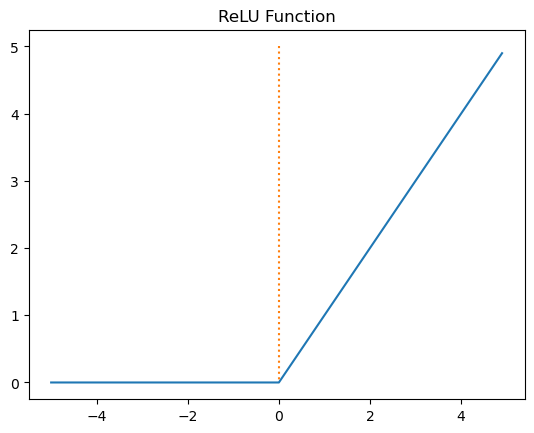

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.title('ReLU Function')
plt.plot(x, y)

plt.plot([0,0], [5.0, 0.0], ':')

plt.show()

#### 리키 렐루(Leaky ReLu) 함수
- 죽은 렐루(dying ReLu):
    - 입력값이 음수면 기울기(미분값)도 0이 됨.
    - 이 뉴런은 다시 회생하는 것이 매우 어려워짐.
- 입력값이 음수일 경우에 0이 아니라 0.001과 같은 매우 작은 수를 반환함.

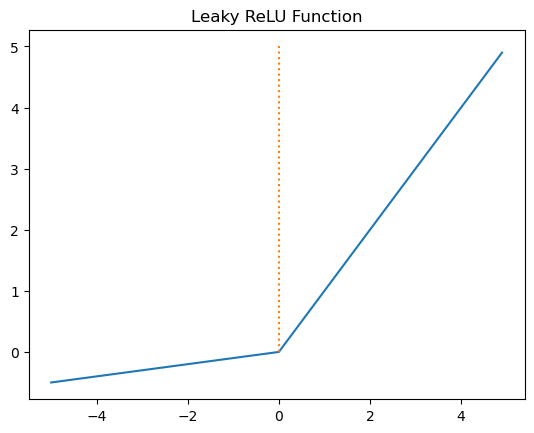

In [95]:
import numpy as np
import matplotlib.pyplot as plt

a = 0.1

def leaky_relu(x):
    return np.maximum(a*x, x)

x = np.arange(-5.0, 5.0, 0.1)
y = leaky_relu(x)

plt.title('Leaky ReLU Function')
plt.plot(x, y)

plt.plot([0,0], [5.0, 0.0], ':')

plt.show()

#### 유방암 데이터 세트
||의학|이진분류|
|---|---|---|
|좋음|악성 종양(정상 종양)|음성 샘플|
|나쁨|악성 종양|양성 샘플(해결 과제)|

In [104]:
from sklearn.datasets import load_breast_cancer
print(load_breast_cancer().DESCR)
load_breast_cancer()

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

(569, 30) (569,)


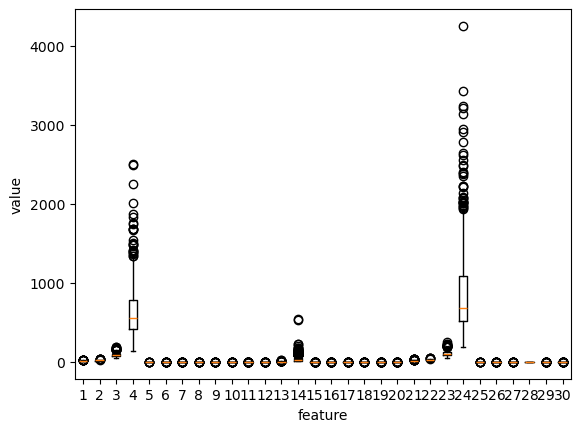

['mean area' 'area error' 'worst area']


(array([0, 1]), array([212, 357], dtype=int64))

In [108]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()

print(cancer.data.shape, cancer.target.shape)

plt.boxplot(cancer.data)
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

print(cancer.feature_names[[3, 13, 23]])

np.unique(cancer.target, return_counts=True)

#### 분류용 데이터 세트
- 학습에 사용한 데이터를 평가에 사용하면 안됨. 구분이 필요.

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

# stratify=y : 훈련/테스트 데이터에 악성/양성 비율이 원본과 동일하게 설정됨
# test_size=0.2: 테스트 데이터와 훈련 데이터의 비율(1:4)
# random_state=42: random seed 값. 동일하면 동일 출력

print(x_train.shape, x_test.shape)


original0 = len([i for i in y if i == 0])
original1 = len([i for i in y if i == 1])

train0 = len([i for i in y_train if i == 0])
train1 = len([i for i in y_train if i == 1])

test0 = len([i for i in y_test if i == 0])
test1 = len([i for i in y_test if i == 1])

print(f'원본 데이터: {original0}:{original1} {original0/original1}' )
print(f'훈련 데이터: {train0}:{train1} {train0/train1}' )
print(f'테스트 데이터: {test0}:{test1} {test0/test1}' )


(455, 30) (114, 30)
원본 데이터: 212:357 0.5938375350140056
훈련 데이터: 170:285 0.5964912280701754
테스트 데이터: 42:72 0.5833333333333334
